In [1]:
#Kernel PCA is an extension of PCA that can find nonlinear patterns in data.
#Original data is transfomred into a higher-dimensional feature space, then pca is applied to.
# problem: new dimension might be too large. Solution: Kernel trick, meaning that instead of.
# Using Kernel function, similarity is calculate without explicitly creating the high-dimensional space.
#commen kernels: linear kernel, polynomial, RBF(Guassian). respectively: K(x , y) = xT y, (xTy + c)^d , e^ (-lambda norm(x - y)^2.

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import KernelPCA

In [6]:
#Load data
data = load_breast_cancer()

x= pd.DataFrame(data.data , columns = data.feature_names)
y = pd.Series(data.target)
x.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
#Check dimensions
print(" number of samples:" , x.shape[0])
print("number of features:" , x.shape[1])

 number of samples: 569
number of features: 30


In [8]:
#Standardized data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [11]:
# Apply Kernel PCA
#gamma shows how much influence each point has.
#small gamma smoother structure, large gamma more complex structure
kpca = KernelPCA(
    n_components = 2,
    kernel= "rbf",
    gamma = 0.03
)

x_kpca = kpca.fit_transform(x_scaled)
#reduce 30 features to 2 nonlinear components

In [13]:
#create data frame
kpca_df = pd.DataFrame(
    x_kpca,
    columns = [
        "kernel PC1",
        "kernel PC2"
    ]
)
# Add target labels
kpca_df["target"] = y.values

kpca_df.head()

,kernel PC1,kernel PC2,target
0,0.397854,0.182639,0
1,0.411138,-0.430391,0
2,0.704703,-0.125100,0
3,0.281110,0.196500,0
4,0.506986,-0.162451,0


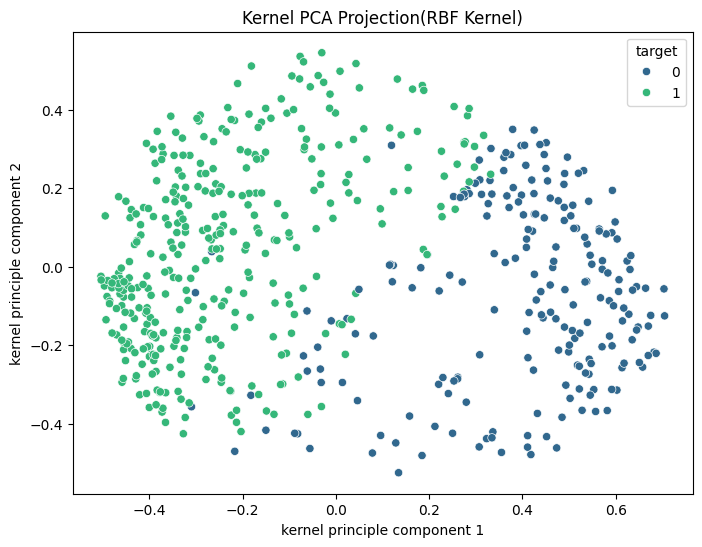

In [17]:
#visualize kernel pca result
plt.figure(figsize = (8,6))
sns.scatterplot(
    data=kpca_df,
    x = "kernel PC1",
    y ="kernel PC2",
    hue ="target",
    palette = "viridis"
)
plt.title("Kernel PCA Projection(RBF Kernel)")
plt.xlabel("kernel principle component 1")
plt.ylabel("kernel principle component 2")
plt.show()

In [18]:
#RESULT: BEFORE KPCA, CLASSES OVERLAP
#AFTER KPCA, CLASSES ARE MORE SEPARATED.